<h1>Look at results summary</h1>

In [22]:
import sys
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 12

print("Setup complete")

Setup complete


In [23]:

import glob
from pathlib import Path
import json
import pandas as pd

print("Searching for summary.json files...")

results = {}
summary_files = list(Path("..").rglob("summary.json"))

for summary_path in summary_files:
    folder = summary_path.parent.name
    try:
        with open(summary_path, encoding="utf-8") as f:
            data = json.load(f)
        test = data.get("final_test", {})
        name = folder.replace("_run", "").replace("staged", " Staged").title()
        if "Swin" in name or "swindamfn" in folder.lower():
            name = "SwinDAMFN Hybrid"
        results[name] = {
            "Accuracy": round(test.get("acc", 0), 4),
            "Precision": round(test.get("precision", 0), 4),
            "Recall": round(test.get("recall", 0), 4),
            "F1-Score": round(test.get("f1", 0), 4),
            "Specificity": round(test.get("specificity", 0), 4),
            "AUC": round(test.get("auc", 0), 4)
        }
        print(f"Loaded {name} from {summary_path}")
    except Exception as e:
        print(f"Error loading {folder}: {e}")

df = pd.DataFrame(results).T.round(4)
print("\n=== FINAL MODEL COMPARISON ===")
display(df)

df.to_csv("../report_figures/final_results_table.csv", index=True)
print("Table saved → report_figures/final_results_table.csv")

Searching for summary.json files...
Loaded Resnet18 from ..\resnet18_run\summary.json
Loaded Resnet50 from ..\resnet50_run\summary.json
Loaded SwinDAMFN Hybrid from ..\swindamfn_staged_run\summary.json

=== FINAL MODEL COMPARISON ===


,Accuracy,Precision,Recall,F1-Score,Specificity,AUC
Resnet18,0.7520,0.6452,0.8108,0.7186,0.7143,0.8200
Resnet50,0.5541,0.4598,0.8108,0.5868,0.3896,0.6534
SwinDAMFN Hybrid,0.7098,0.5841,0.8919,0.7059,0.5931,0.8292


Table saved → report_figures/final_results_table.csv


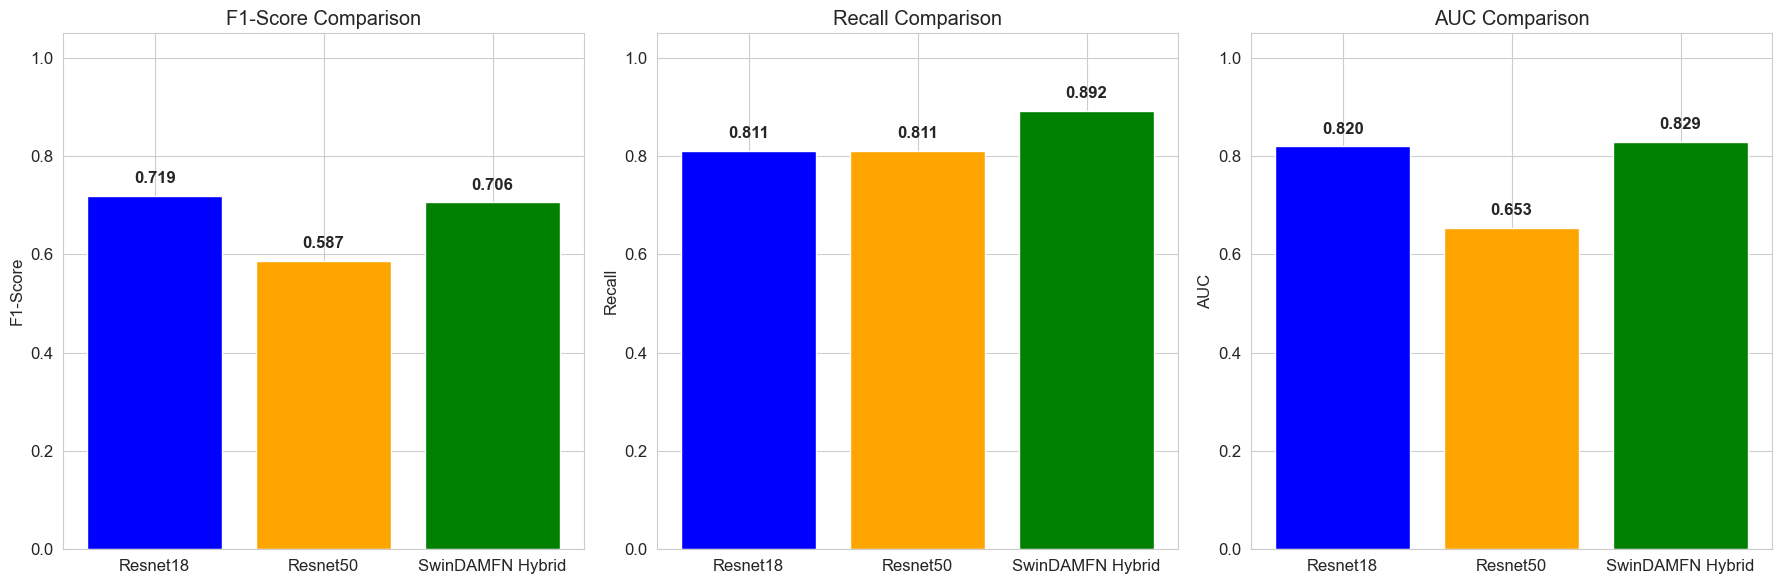

In [24]:
metrics = ["F1-Score", "Recall", "AUC"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ["blue", "orange", "green"]

for i, metric in enumerate(metrics):
    values = df[metric]
    bars = axes[i].bar(df.index, values, color=colors)
    axes[i].set_title(f"{metric} Comparison")
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1.05)
    axes[i].grid(True, axis="y")
    
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                     f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("report_figures/final_comparison_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
best_model = df["F1-Score"].idxmax()
print(f"   BEST MODEL: **{best_model}**")
print(f"   F1-Score : {df.loc[best_model, 'F1-Score']:.4f}")
print(f"   Recall   : {df.loc[best_model, 'Recall']:.4f}")
print(f"   AUC      : {df.loc[best_model, 'AUC']:.4f}")

# Save for report
df.to_csv("report_figures/final_results_table.csv")
print("\nTable saved report_figures/final_results_table.csv Table saved as report_figures/final_results_table.csv")

   BEST MODEL: **Resnet18**
   F1-Score : 0.7186
   Recall   : 0.8108
   AUC      : 0.8200

Table saved report_figures/final_results_table.csv Table saved as report_figures/final_results_table.csv
